In [1]:

import os
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel("QUALITY & DEFECT REDUCTION.xlsx")
print(df.head())

            Timestamp  MachineID    Plant  Temperature  Vibration   Pressure  \
0 2025-01-01 00:00:00        142  Plant_B    77.474270   2.604480  23.438160   
1 2025-01-01 01:00:00        124  Plant_C    72.435288   6.240213  30.236166   
2 2025-01-01 02:00:00        103  Plant_A    59.063863   6.470758  32.778778   
3 2025-01-01 03:00:00        108  Plant_C    63.859148   3.646682  26.077120   
4 2025-01-01 04:00:00        100  Plant_B    76.799275   5.261242  33.432417   

   EnergyConsumption  ProductionUnits  DefectCount  MaintenanceFlag  
0         315.443998               52            4                0  
1         300.579876               89            1                0  
2         240.961506              194            0                0  
3         206.954154              190            2                0  
4         259.130150              173            8                1  


In [3]:
df_model = df.drop(columns=["Timestamp", "Plant"])

# Define X (features) and y (target)
X = df_model.drop(columns=["DefectCount"])
y = df_model["DefectCount"]

print("Features:")
print(X.columns)


Features:
Index(['MachineID', 'Temperature', 'Vibration', 'Pressure',
       'EnergyConsumption', 'ProductionUnits', 'MaintenanceFlag'],
      dtype='object')


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = model.predict(X_test)

In [7]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 3.146106075
R2 Score: -0.03100347566884354


In [8]:
df_model = df.drop(columns=["Timestamp", "Plant", 
                            "MachineID", 
                            "MaintenanceFlag"])

X = df_model.drop(columns=["DefectCount"])
y = df_model["DefectCount"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression Results")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


Linear Regression Results
MSE: 3.0540506159296035
R2: -0.0008361844226734139


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Results")
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("R2:", r2_score(y_test, y_pred_gb))


Gradient Boosting Results
MSE: 3.075734891750039
R2: -0.007942290575890354


In [11]:
df["DefectRate"] = df["DefectCount"] / df["ProductionUnits"]

In [12]:
df_model = df.drop(columns=[
    "Timestamp",
    "Plant",
    "MachineID",
    "DefectCount"
])

X = df_model.drop(columns=["DefectRate"])
y = df_model["DefectRate"]


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MSE: 0.0003118717221695847
R2: 0.2967211921486992


In [14]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)


             Feature  Importance
4    ProductionUnits    0.925580
1          Vibration    0.020008
2           Pressure    0.019067
3  EnergyConsumption    0.017899
0        Temperature    0.016648
5    MaintenanceFlag    0.000798


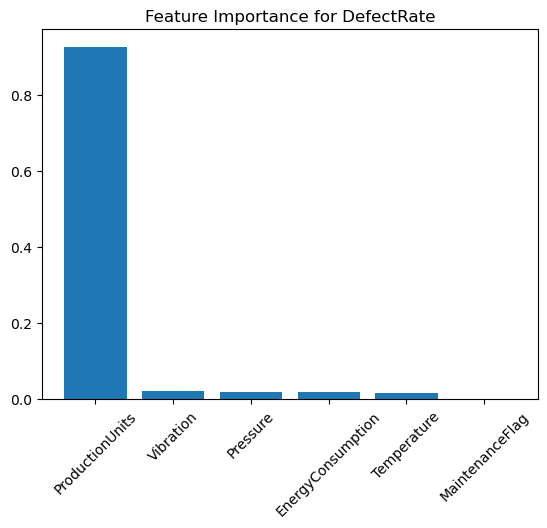

In [15]:
plt.figure()
plt.bar(importance_df["Feature"],
        importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for DefectRate")
plt.show()

In [16]:
df_model = df.drop(columns=[
    "Timestamp",
    "Plant",
    "MachineID",
    "DefectCount",
    "ProductionUnits"
])

X = df_model.drop(columns=["DefectRate"])
y = df_model["DefectRate"]


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MSE: 0.0004460045675333836
R2: -0.0057518468460340255


In [18]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

             Feature  Importance
1          Vibration    0.331693
0        Temperature    0.252789
3  EnergyConsumption    0.214757
2           Pressure    0.194508
4    MaintenanceFlag    0.006253


In [19]:
df["DefectRate"] = df["DefectCount"] / df["ProductionUnits"]

In [20]:
machine_mean = df.groupby("MachineID").agg({
    "DefectRate": "mean",
    "Vibration": "mean",
    "Temperature": "mean",
    "Pressure": "mean"
}).reset_index()


In [21]:
print("Machine Mean Data:")
print(machine_mean.head())

Machine Mean Data:
   MachineID  DefectRate  Vibration  Temperature   Pressure
0        100    0.028896   5.119509    69.729144  30.550820
1        101    0.027600   4.937900    70.082934  30.169352
2        102    0.026264   4.948084    69.981160  29.947623
3        103    0.027602   5.048506    70.219775  30.119664
4        104    0.028507   5.023351    69.679257  29.725638


In [22]:
features = ["DefectRate", "Vibration", "Temperature", "Pressure"]

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(machine_mean[features])

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
machine_mean["Cluster"] = kmeans.fit_predict(scaled_data)

In [26]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(centers, columns=features)

print("\nCluster Centers:")
print(cluster_centers)



Cluster Centers:
   DefectRate  Vibration  Temperature   Pressure
0    0.027661   5.004555    70.566061  30.006705
1    0.027693   5.000364    69.842391  29.884812
2    0.028874   4.973216    69.660755  30.254396


In [27]:
cluster_labels = {}

for i in range(len(cluster_centers)):
    row = cluster_centers.loc[i]

    if row["DefectRate"] > cluster_centers["DefectRate"].mean() and \
       row["Vibration"] > cluster_centers["Vibration"].mean():
        cluster_labels[i] = "High Defect / High Vibration"

    elif row["DefectRate"] > cluster_centers["DefectRate"].mean():
        cluster_labels[i] = "High Defect"

    elif row["Vibration"] > cluster_centers["Vibration"].mean():
        cluster_labels[i] = "High Vibration"

    else:
        cluster_labels[i] = "Normal Operation"

machine_mean["ClusterLabel"] = machine_mean["Cluster"].map(cluster_labels)

In [28]:
summary = machine_mean.groupby("ClusterLabel").agg({
    "MachineID": "count",
    "DefectRate": "mean",
    "Vibration": "mean",
    "Temperature": "mean",
    "Pressure": "mean"
}).rename(columns={"MachineID": "MachineCount"})

print("\nFinal Cluster Summary:")
print(summary)


Final Cluster Summary:
                MachineCount  DefectRate  Vibration  Temperature   Pressure
ClusterLabel                                                               
High Defect                6    0.028874   4.973216    69.660755  30.254396
High Vibration            44    0.027681   5.001983    70.121991  29.931907
